<a href="https://colab.research.google.com/github/ha486-gk/DeepLearning/blob/main/RL_Blackjack.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

RL- Blackjack

In [ ]:
# 1. 라이브러리 설치 (매번 실행 필요)
!pip install gymnasium[toy_text]

import os
import numpy as np
import gymnasium as gym

# 2. 드라이브 내 프로젝트 폴더 설정 (수동 마운트 후 실행)
# 'MyDrive' 뒤의 경로는 본인이 구글 드라이브에 만든 폴더 이름으로 수정하세요.
MY_PATH = '/content/drive/MyDrive/RL_Project/Blackjack/'

# 폴더가 없으면 자동으로 만들어주는 안전 장치
if not os.path.exists(MY_PATH):
    os.makedirs(MY_PATH)
    print(f"새 폴더를 생성했습니다: {MY_PATH}")
else:
    print(f"기존 폴더를 연결했습니다: {MY_PATH}")

기존 폴더를 연결했습니다: /content/drive/MyDrive/RL_Project/Blackjack/


환경 구성

In [ ]:
import gymnasium as gym
import numpy as np
from collections import defaultdict
# dict의 default class를 지정해준다. 지정되지 않은 key의 값을 초기화한다.
# defaultdict(int) 이면 키의 초깃값이 0으로 지정, list이면 [] 등으로 초기화됨. 이후 키의 값을 다른 class로 변경 가능

env = gym.make('Blackjack-v1')

MC ES

MC ES 기법을 사용하니 숫자합이 작은구간에 대한 탐험이 적은 문제가 생김.

그래도, 학습횟수 늘리면 골고루 분포됨.
50만회 학습/ 50만회 테스트 결과 승률은 43.3%.

입실론 탐욕적 코드 실행 결과 (epsilon_decay 방법 사용; 최적해로 수렴하도록)

50만회 학습/ 50만회 테스트 결과 승률은 46.4%.

두 방법 모두 정책과 가치함수도 이론상 결과와 유사.

입실론 탐욕적은 초기 탐험때문에 초기 승률이 ES보다 좋지는 않음. 하지만 최종에서는 조금 더 높은 승률을 보임.

근소하지만 입실론 탐욕적이 ES보다 좋고 usable ace True의 경우 policy가 더 정확해보임.

승률이 유사한 이유는 블랙잭 환경이 상태 공간이 작고, 최적정책이 비교적 명확하여 50만회 학습하면 유사하게 나온다고 생각됨.

최적 승률이 42~44%인것을 감안하면 이는 무시할만한 승률차이라고 생각됨.(상태 방문 빈도도 대부분 무한히 탐색한것으로 보임)


In [ ]:
# 1. Q-Table 생성 (상태별 행동의 가치를 저장할 딕셔너리)
# 상태 예시: (내 점수, 딜러 점수, 에이스 유무)
Q = defaultdict(lambda: np.zeros(env.action_space.n)) # lambda는 익명의 0행렬 객체를 호출해주는 익명 함수
# key = state, value = [Hit가치, Stand 가치]
C = defaultdict(lambda: np.zeros(env.action_space.n)) # 상태-행동쌍 방문횟수, 점증적 구현을 위함.
# policy 변수의 필요성 부재
# why? 이 문제의 경우 Q의 argmax 인덱스 값이 바로 policy랑 같은 의미이기 때문

# 시작 탐험 가정
def get_action_exploring_starts(state):
  return env.action_space.sample() # Hit(1), Stand(0) 둘 중 무작위 추출

def get_action(state):
  return np.argmax(Q[state]) # argmax는 max값의 인덱스를 반환

# 2. 에피소드 만들기 - episodic task
def get_episode():
  episode = []
  state, info = env.reset()
  action = get_action_exploring_starts(state)
  while True:
      next_state, reward, terminated, truncated, info = env.step(action)
      episode.append((state, action, reward))
      if terminated or truncated:
          break
      state = next_state
      action = get_action(state)
  return episode

# 3. 학습

epoch = 100000

for i in range(epoch):
  episode = get_episode()
  states, actions, rewards = zip(*episode) # state, action, rewards 모두 각각 튜플로 저장됨
  Gt = 0

  for t in range(len(states)-2,-1,-1):
    Gt = Gt+ rewards[t+1] # 할인율 1 가정, 보상이 terminate 이후에 있으므로
    visit_before = False
    for j in range(t):
      if states[j] == states[t] and actions[j] == actions[t]:
        visit_before = True
        break
    if not visit_before:
      C[states[t]][actions[t]] += 1
      Q[states[t]][actions[t]] += (Gt - Q[states[t]][actions[t]]) / C[states[t]][actions[t]] # 점증적 구현

print(f"{epoch}회 학습이 수행되었습니다.")

100000회 학습이 수행되었습니다.


### 학습 과정 모니터링

학습을 시작합니다...

============================== Episode 1000 Checkpoint ==============================
현재 승률: 40.9%


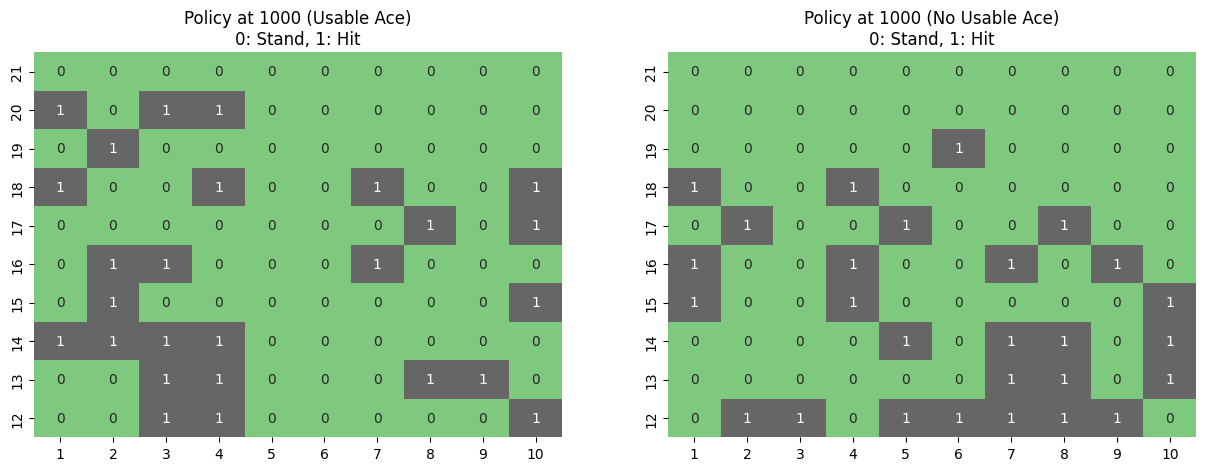

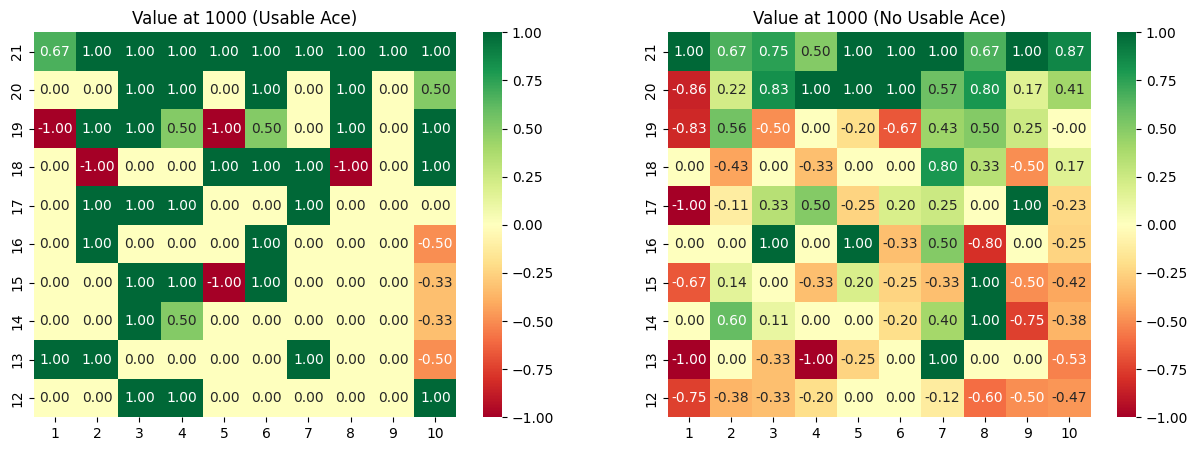


============================== Episode 10000 Checkpoint ==============================
현재 승률: 44.9%


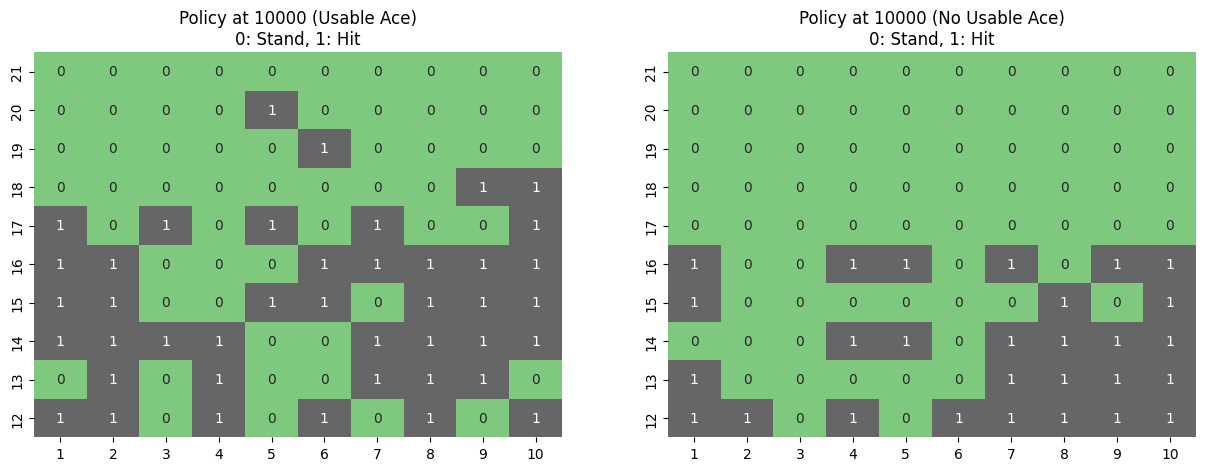

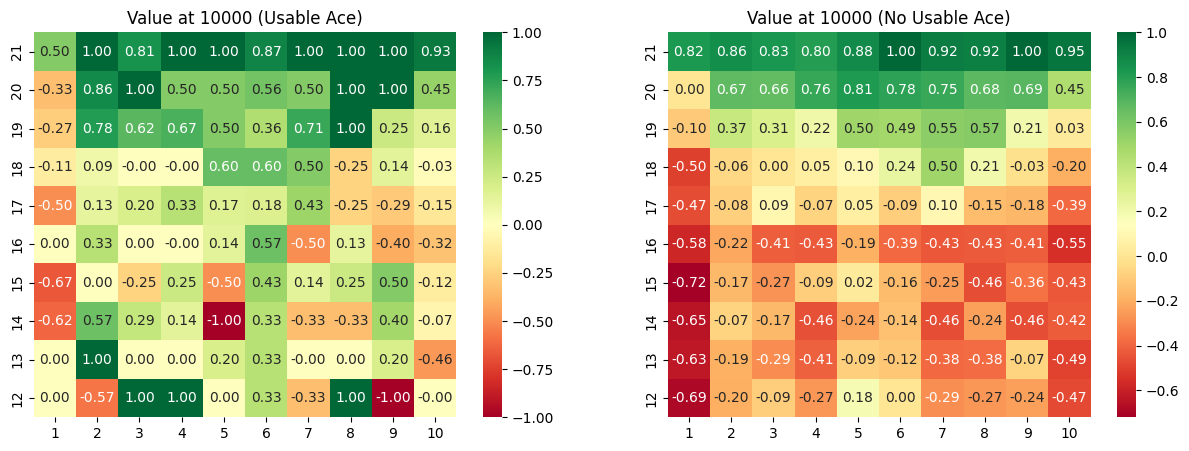


============================== Episode 100000 Checkpoint ==============================
현재 승률: 43.6%


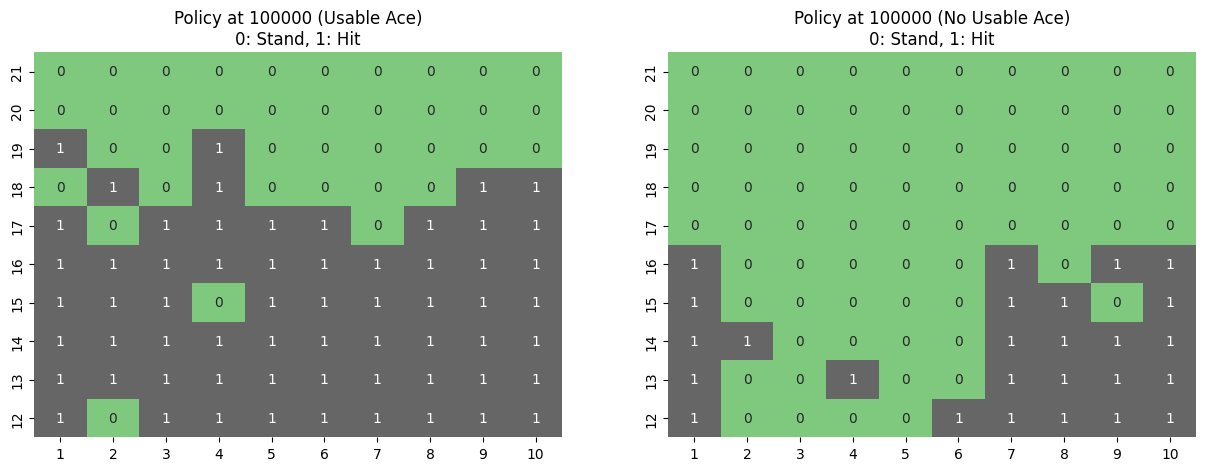

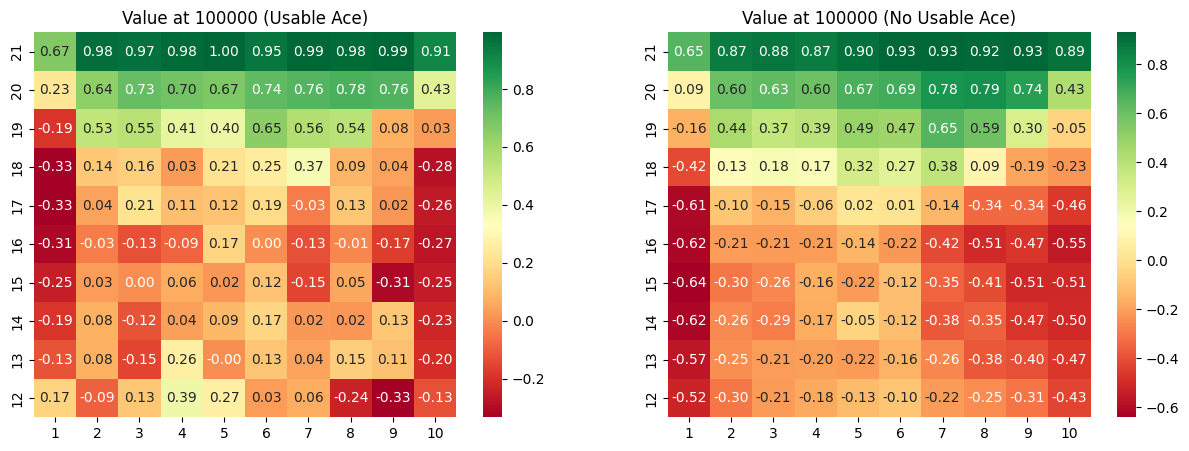


============================== Episode 500000 Checkpoint ==============================
현재 승률: 40.0%


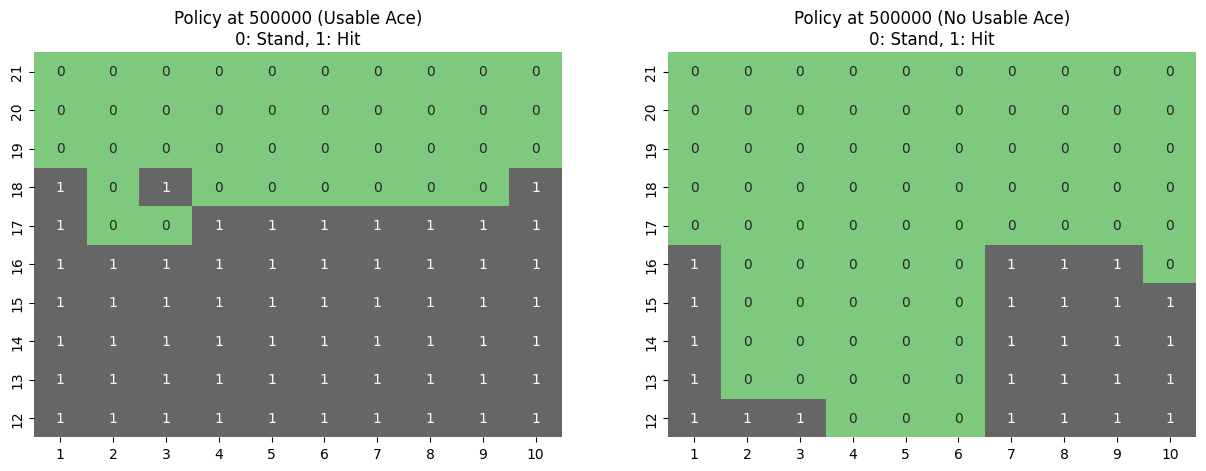

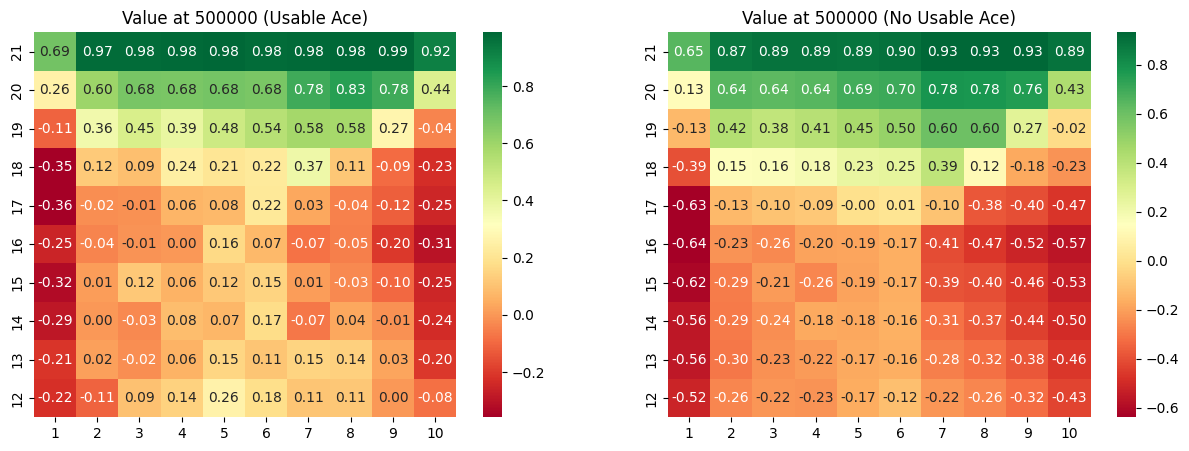

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import defaultdict

def plot_policy(Q, title="Policy"):
    player_range = np.arange(12, 22)
    dealer_range = np.arange(1, 11)
    Pi_ace = np.zeros((len(player_range), len(dealer_range)))
    Pi_no_ace = np.zeros((len(player_range), len(dealer_range)))
    for i, p in enumerate(player_range):
        for j, d in enumerate(dealer_range):
            Pi_ace[i, j] = np.argmax(Q.get((p, d, True), [0, 0]))
            Pi_no_ace[i, j] = np.argmax(Q.get((p, d, False), [0, 0]))
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    # 라벨 수정: 0은 Stand(Stick), 1은 Hit
    sns.heatmap(Pi_ace, xticklabels=dealer_range, yticklabels=player_range, ax=axes[0], annot=True, cbar=False, cmap='Accent')
    axes[0].set_title(f'{title} (Usable Ace)\n0: Stand, 1: Hit')
    axes[0].invert_yaxis()
    sns.heatmap(Pi_no_ace, xticklabels=dealer_range, yticklabels=player_range, ax=axes[1], annot=True, cbar=False, cmap='Accent')
    axes[1].set_title(f'{title} (No Usable Ace)\n0: Stand, 1: Hit')
    axes[1].invert_yaxis()
    plt.show()

def plot_value_function(Q, title="State Value"):
    player_range = np.arange(12, 22)
    dealer_range = np.arange(1, 11)
    V_ace = np.zeros((len(player_range), len(dealer_range)))
    V_no_ace = np.zeros((len(player_range), len(dealer_range)))
    for i, p in enumerate(player_range):
        for j, d in enumerate(dealer_range):
            V_ace[i, j] = np.max(Q.get((p, d, True), [0, 0]))
            V_no_ace[i, j] = np.max(Q.get((p, d, False), [0, 0]))
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    sns.heatmap(V_ace, xticklabels=dealer_range, yticklabels=player_range, ax=axes[0], annot=True, fmt='.2f', cmap='RdYlGn')
    axes[0].set_title(f'{title} (Usable Ace)')
    axes[0].invert_yaxis()
    sns.heatmap(V_no_ace, xticklabels=dealer_range, yticklabels=player_range, ax=axes[1], annot=True, fmt='.2f', cmap='RdYlGn')
    axes[1].set_title(f'{title} (No Usable Ace)')
    axes[1].invert_yaxis()
    plt.show()

def evaluate_policy_internal(Q, n_episodes=1000):
    wins = 0
    for _ in range(n_episodes):
        state, info = env.reset()
        done = False
        while not done:
            action = np.argmax(Q.get(state, [0, 0]))
            state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
        if reward > 0: wins += 1
    return (wins / n_episodes) * 100

# 초기화 및 학습 루프
Q = defaultdict(lambda: np.zeros(env.action_space.n))
C = defaultdict(lambda: np.zeros(env.action_space.n))
checkpoints = [1000,10000, 100000, 500000]

print("학습을 시작합니다...")
for i in range(1, max(checkpoints) + 1):
    episode = get_episode()
    states, actions, rewards = zip(*episode)
    Gt = 0
    for t in range(len(states)-1, -1, -1):
        Gt += rewards[t]
        visited_before = False
        for j in range(t):
            if states[j] == states[t] and actions[j] == actions[t]:
                visited_before = True
                break
        if not visited_before:
            C[states[t]][actions[t]] += 1
            Q[states[t]][actions[t]] += (Gt - Q[states[t]][actions[t]]) / C[states[t]][actions[t]]

    if i in checkpoints:
        win_rate = evaluate_policy_internal(Q)
        print(f"\n{'='*30} Episode {i} Checkpoint {'='*30}")
        print(f"현재 승률: {win_rate:.1f}%")
        plot_policy(Q, f"Policy at {i}")
        plot_value_function(Q, f"Value at {i}")

### 정책 평가 (Win Rate Test)
학습된 정책이 실제로 얼마나 이기는지 확인해봅시다. (500000판 기준)

In [ ]:

def evaluate_policy(Q, n_episodes=500000):
    wins = 0
    draws = 0
    losses = 0

    for _ in range(n_episodes):
        state, info = env.reset()
        terminated = False
        truncated = False

        while not (terminated or truncated):
            # 학습된 Q-table에 따라 최선의 행동 선택
            action = np.argmax(Q.get(state, [0, 0]))
            state, reward, terminated, truncated, info = env.step(action)

        if reward > 0:
            wins += 1
        elif reward == 0:
            draws += 1
        else:
            losses += 1

    print(f"테스트 결과 ({n_episodes}판):")
    print(f"승리: {wins} ({wins/n_episodes*100:.1f}%)")
    print(f"무승부: {draws} ({draws/n_episodes*100:.1f}%)")
    print(f"패배: {losses} ({losses/n_episodes*100:.1f}%)")

# 학습된 Q-table을 사용하여 정책 평가 수행
evaluate_policy(Q, n_episodes=500000)



테스트 결과 (500000판):
승리: 216381 (43.3%)
무승부: 44429 (8.9%)
패배: 239190 (47.8%)


### 상태별 방문 횟수(C) 시각화
특정 상태가 얼마나 자주 탐험되었는지 확인하여 학습의 신뢰도를 평가합니다.

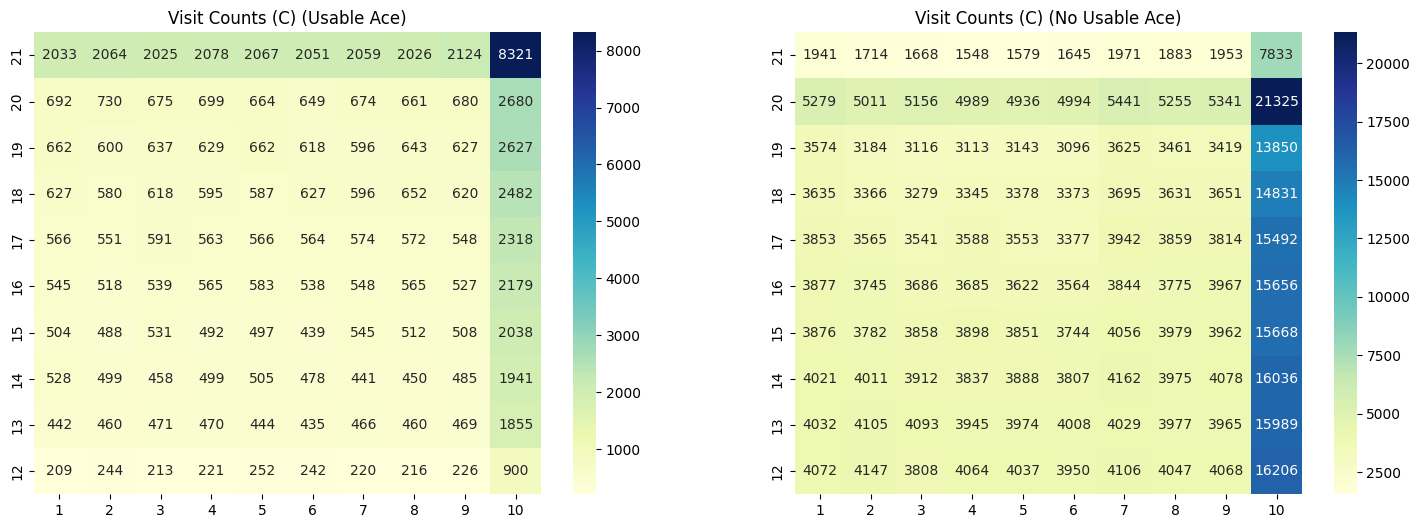

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_visit_counts(C, title="Visit Counts (C)"):
    player_range = np.arange(12, 22)
    dealer_range = np.arange(1, 11)

    # 방문 횟수의 합산 (Hit/Stand 합계)
    C_ace = np.zeros((len(player_range), len(dealer_range)))
    C_no_ace = np.zeros((len(player_range), len(dealer_range)))

    for i, p in enumerate(player_range):
        for j, d in enumerate(dealer_range):
            C_ace[i, j] = np.sum(C.get((p, d, True), [0, 0]))
            C_no_ace[i, j] = np.sum(C.get((p, d, False), [0, 0]))

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # Usable Ace Heatmap
    sns.heatmap(C_ace, xticklabels=dealer_range, yticklabels=player_range,
                ax=axes[0], annot=True, fmt='.0f', cmap='YlGnBu')
    axes[0].set_title(f'{title} (Usable Ace)')
    axes[0].invert_yaxis()

    # No Usable Ace Heatmap
    sns.heatmap(C_no_ace, xticklabels=dealer_range, yticklabels=player_range,
                ax=axes[1], annot=True, fmt='.0f', cmap='YlGnBu')
    axes[1].set_title(f'{title} (No Usable Ace)')
    axes[1].invert_yaxis()

    plt.show()

# 방문 횟수 시각화 실행
plot_visit_counts(C)

MC epsilon Greedy

In [ ]:
Q_epsilon = defaultdict(lambda: np.zeros(env.action_space.n))
C_epsilon = defaultdict(lambda: np.zeros(env.action_space.n))

# 시작 탐험 가정 필요 없음

epoch = 100000
start_epsilon = 0.2
end_epsilon = 0.01
epsilon_decay = (start_epsilon - end_epsilon) / epoch

def get_action(state, epsilon):
    if np.random.random() < epsilon:
        return env.action_space.sample()
    return np.argmax(Q_epsilon[state])

def get_episode(epsilon):
    episode = []
    state, info = env.reset()
    action = get_action(state, epsilon)
    while True:
        next_state, reward, terminated, truncated, info = env.step(action)
        episode.append((state, action, reward))
        if terminated or truncated:
            break
        state = next_state
        action = get_action(state, epsilon)
    return episode

for i in range(epoch):
    current_epsilon = start_epsilon - i * epsilon_decay
    episode = get_episode(current_epsilon)
    states, actions, rewards = zip(*episode)
    Gt = 0
    for t in range(len(states)-1, -1, -1):
        Gt += rewards[t]
        visit_before = False
        for j in range(t):
            if states[j] == states[t] and actions[j] == actions[t]:
                visit_before = True
                break
        if not visit_before:
            C_epsilon[states[t]][actions[t]] += 1
            Q_epsilon[states[t]][actions[t]] += (Gt - Q_epsilon[states[t]][actions[t]]) / C_epsilon[states[t]][actions[t]]

print(f'{epoch}회 학습이 수행되었습니다. (Q_epsilon)')

100000회 학습이 수행되었습니다. (Q_epsilon)


### MC Epsilon-Greedy 학습 및 실시간 모니터링

설정한 `epoch` 동안 학습하며, 특정 체크포인트마다 승률 계산 및 정책/가치 함수 히트맵을 출력합니다.

500000회 학습을 시작합니다 (Epsilon-Greedy)...

Checkpoint Episode 1000: Win Rate 40.2%


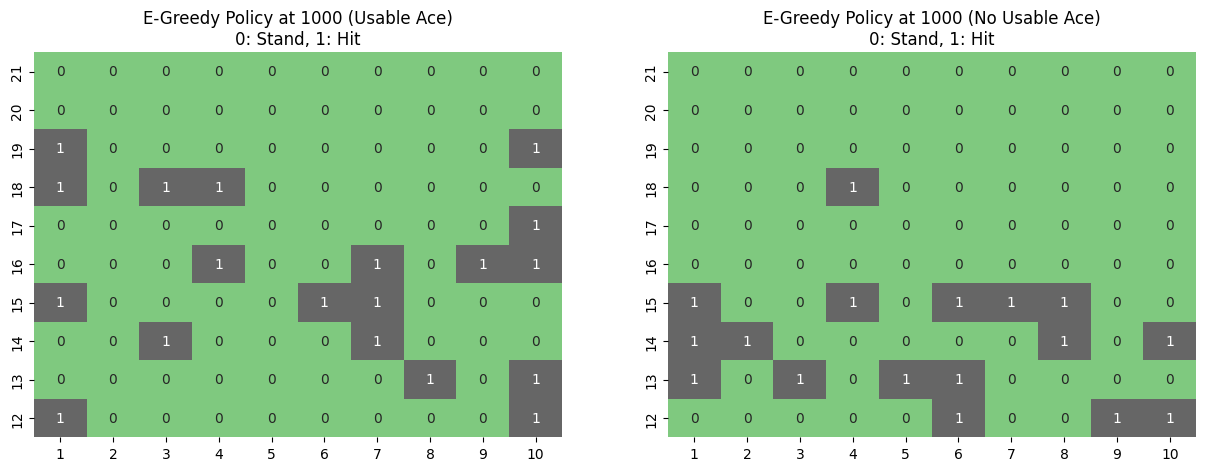

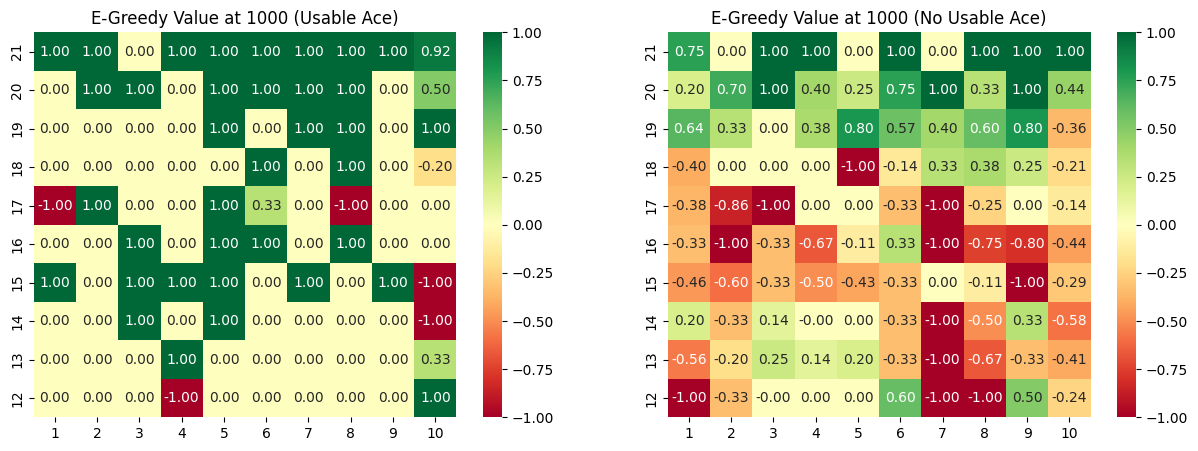


Checkpoint Episode 10000: Win Rate 41.2%


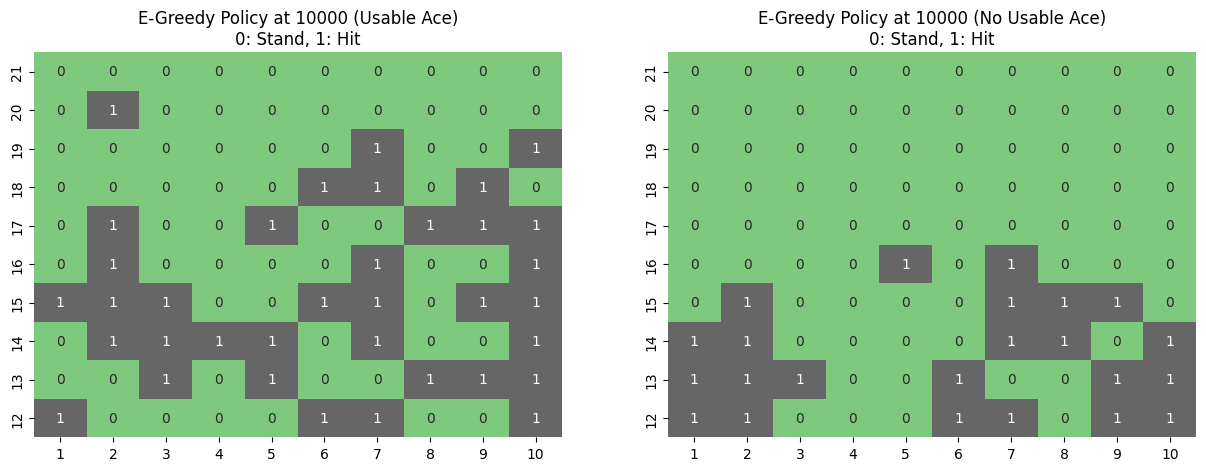

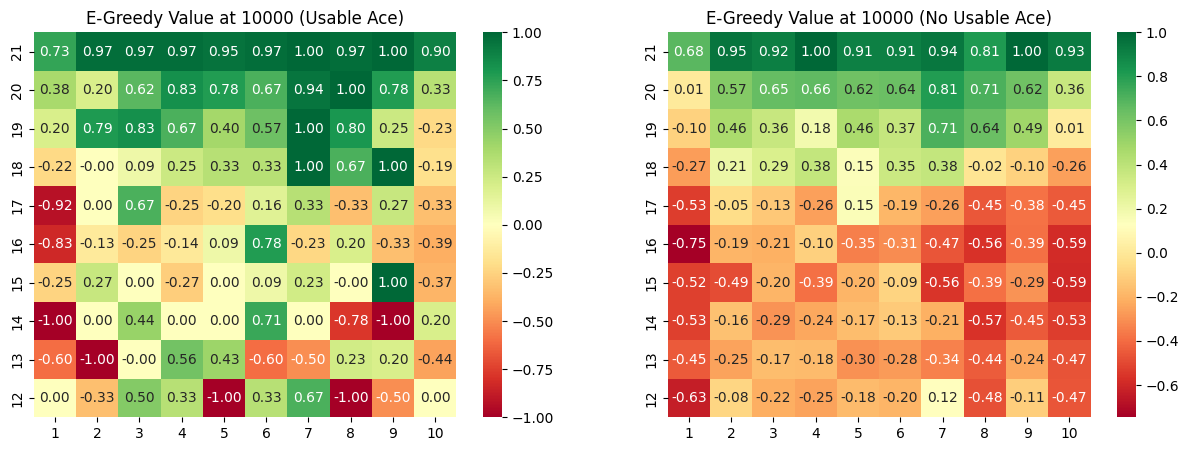


Checkpoint Episode 100000: Win Rate 43.5%


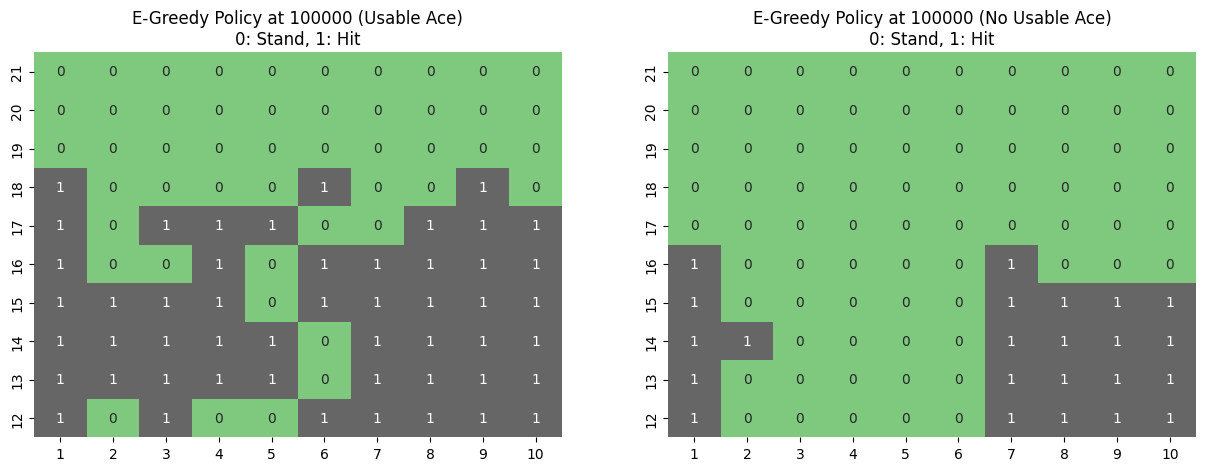

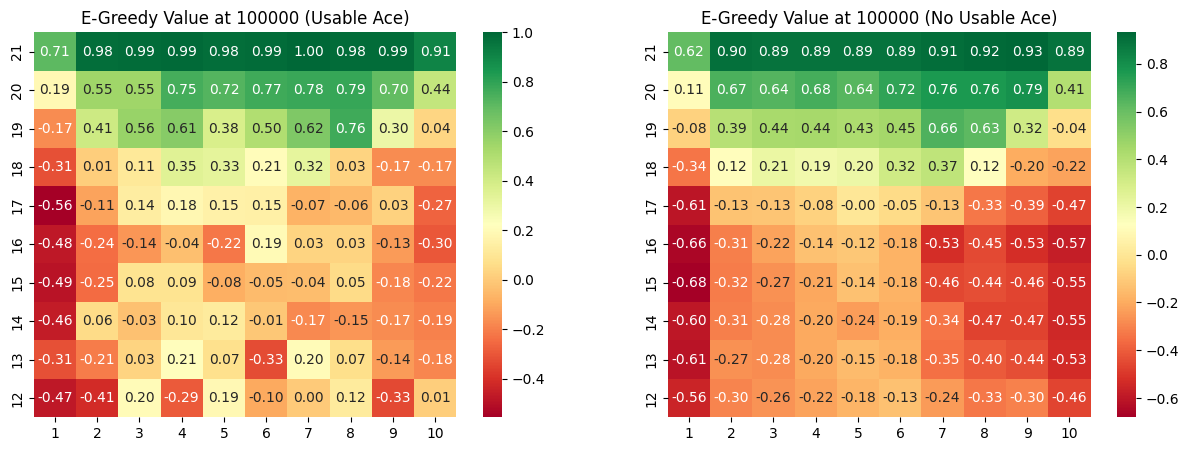


Checkpoint Episode 500000: Win Rate 46.4%


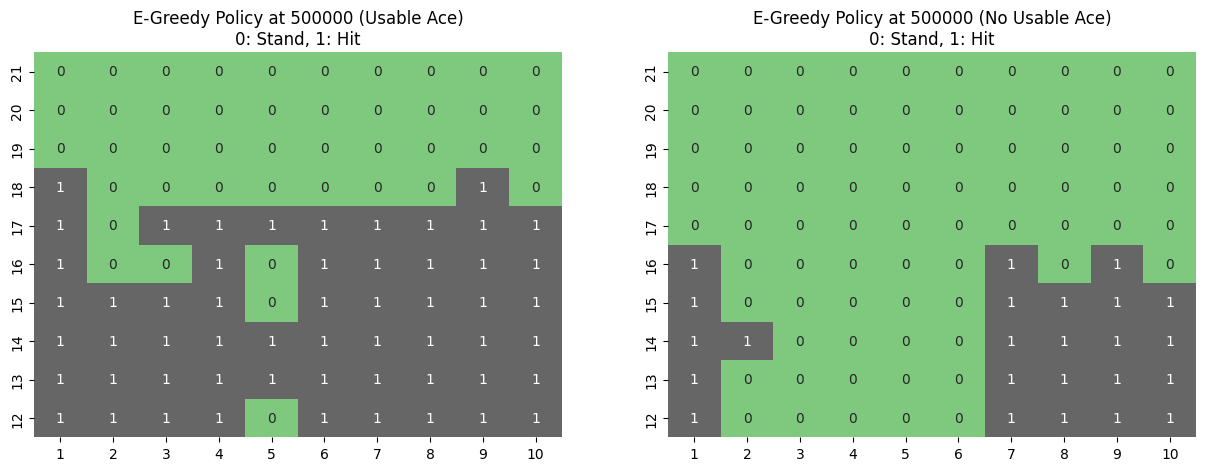

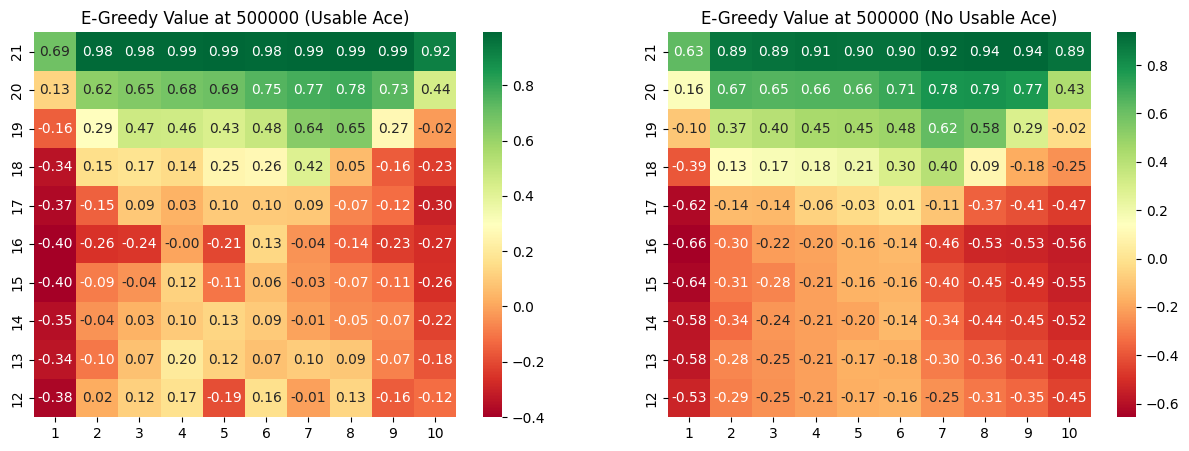

In [ ]:
Q_epsilon = defaultdict(lambda: np.zeros(env.action_space.n))
C_epsilon = defaultdict(lambda: np.zeros(env.action_space.n))

epoch = 500000
start_epsilon = 0.2
end_epsilon = 0.01
epsilon_decay = (start_epsilon - end_epsilon) / epoch
checkpoints = [1000, 10000, 100000, 500000]

print(f'{epoch}회 학습을 시작합니다 (Epsilon-Greedy)...')

for i in range(1, epoch + 1):
    current_epsilon = max(end_epsilon, start_epsilon - i * epsilon_decay)
    episode = get_episode(current_epsilon)
    states, actions, rewards = zip(*episode)
    Gt = 0
    for t in range(len(states)-1, -1, -1):
        Gt += rewards[t]
        visited_before = False
        for j in range(t):
            if states[j] == states[t] and actions[j] == actions[t]:
                visited_before = True
                break
        if not visited_before:
            C_epsilon[states[t]][actions[t]] += 1
            Q_epsilon[states[t]][actions[t]] += (Gt - Q_epsilon[states[t]][actions[t]]) / C_epsilon[states[t]][actions[t]]

    if i in checkpoints:
        win_rate = evaluate_policy_internal(Q_epsilon)
        print(f'\nCheckpoint Episode {i}: Win Rate {win_rate:.1f}%')
        plot_policy(Q_epsilon, f'E-Greedy Policy at {i}')
        plot_value_function(Q_epsilon, f'E-Greedy Value at {i}')

### 상태별 방문 횟수(C) 시각화
특정 상태가 얼마나 자주 탐험되었는지 확인하여 학습의 신뢰도를 평가합니다.

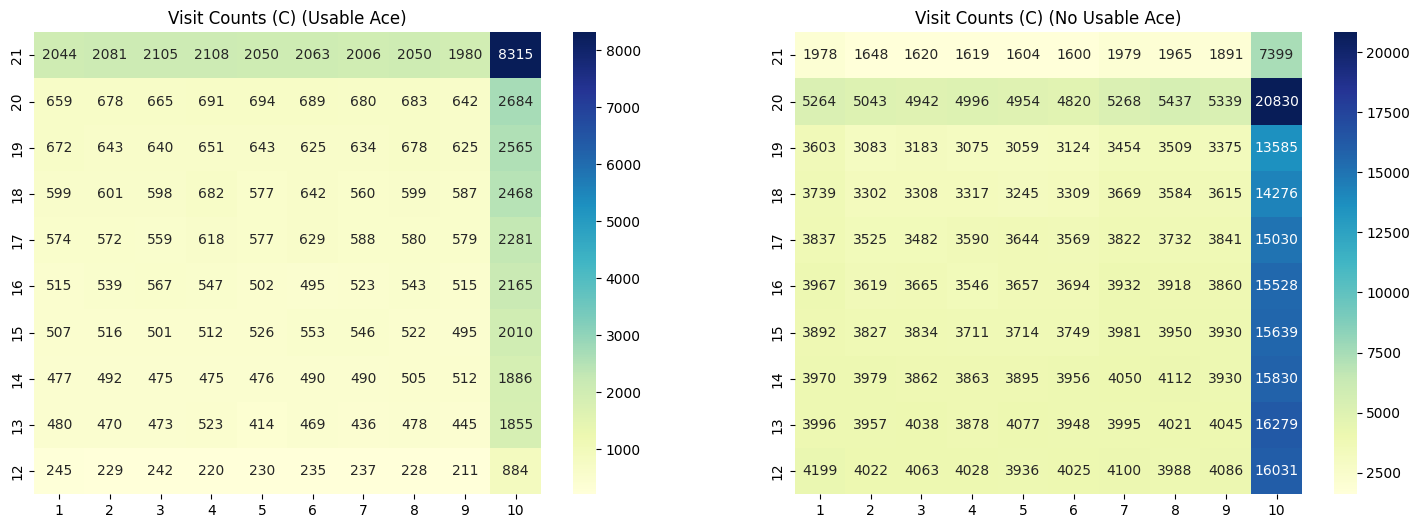

In [ ]:
plot_visit_counts(C_epsilon, title='Visit Counts (C_epsilon)')

### 정책 평가 (Win Rate Test)
학습된 정책이 실제로 얼마나 이기는지 확인해봅시다. (500000판 기준)

In [ ]:
evaluate_policy(Q_epsilon, n_episodes=500000)

테스트 결과 (500000판):
승리: 216015 (43.2%)
무승부: 43762 (8.8%)
패배: 240223 (48.0%)
